In [63]:
# Initialize Otter
import otter
grader = otter.Notebook("hwk1-task3-earthquakes.ipynb")

# Task 3: `pandas` fundamentals with earthquake data

## Instructions
- First, update the following cell to have a link to *your* Homework 1 GitHub repository:

**UPDATE THIS LINK:**

[https://github.com/roshananair/eds220-hwk1]()

- This task covers topics on the lessons on [subsetting `pandas.DataFrames`](https://meds-eds-220.github.io/MEDS-eds-220-course/book/chapters/lesson-3-pandas-subsetting/lesson-3-pandas-subsetting.html) and [plotting](). The best strategy to solve it is to get together with your classmates and work on it together after these lecture.

- Review the [complete rubric for this task](https://docs.google.com/document/d/131OnUDOLpOl94SlaMU9nGqT998ABrjFS/edit?usp=sharing&ouid=111507336322611936333&rtpof=true&sd=true) before starting.

- **Make at least 5 commits at moments you think are adequate.** We'll check your repository and view the commit history.

- **Add comments for all your code.** Err on the side of commenting too much for now. Comments should follow best practices.


## Acknowledgement
This task was adapted from the *Pandas Fundamentals with Earthquake Data* assignment from the e-book [Earth and Environmental Data Science](https://earth-env-data-science.github.io/intro.html)

## About the data

For this task we are going to use simplified data from the [USGS Earthquakes Database](https://earthquake.usgs.gov/earthquakes/search/). This dataset is given in a single CSV file within the`data` folder (`data/earthquake_data.csv`) and has the following columns:

- time = date and time of event (all events from 2014)
- latitude = decimal degrees [-90,90]
- longitude = decimal degrees [-360,360]
- depth = depth of the event (km)
- mag =  magnitude of event
- id = event identifier
- place = where the event took place
- type = type of event

<!-- BEGIN QUESTION -->

## 1 

a. Import pandas (always with standard abbreviation!).

b. Use `pd.read_csv()` to import the `earthquake_data.csv` dataset and store it in the `raw_eqk` variable.


In [64]:
# Initialising pandas
import pandas as pd

# Reading in data
raw_eqk = pd.read_csv('data/earthquake_data.csv')

<!-- END QUESTION -->

Look at the head of the dataframe. Store the result in the `raw_eqk_head` variable. 

In [65]:
# Pulling the first five rows of raw data
raw_eqk_head = raw_eqk.head()

In [66]:
# View the dataframe
raw_eqk_head

,time,latitude,longitude,depth,mag,id,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ak11155107,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,nn00436847,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ak11151142,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ak11151135,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ci37171541,"10km WNW of Progreso, Mexico",earthquake


In [67]:
grader.check("q1_c")

q1_c results: All test cases passed!

## 2
a. Print the shape of the `raw_eqk` dataframe. Store your answer in the `raw_eqk_shape` variable.

In [68]:
# Pulling the shape of the raw data (rows, columns)
raw_eqk_shape = raw_eqk.shape
raw_eqk_shape

(120108, 8)

In [69]:
grader.check("q2_a")

q2_a results: All test cases passed!

b. Store the type of `raw_eqk`'s shape in the `raw_eqk_shape_type` variable.

In [70]:
# Pulling the type of the shape variable
raw_eqk_shape_type = type(raw_eqk_shape)

In [71]:
# View the dataframe
raw_eqk_shape_type

tuple

In [72]:
grader.check("q2_b")

q2_b results: All test cases passed!

c. Extract *only* the number of rows by accessing it from `raw_eqk`'s shape.Store your answer in the `num_rows` variable.  HINT: how do you index an element in a tuple?

In [73]:
# Indexing the shape variable to extract number of rows
num_rows = raw_eqk_shape[0]
num_rows

120108

In [74]:
grader.check("q2_c")

q2_c results: All test cases passed!

## 3

Get the unique values of the type of events. Store your answer in the `unique_events` variable.

In [75]:
# Finding the number of unique types of events by using the type column and .nunique()
unique_events = raw_eqk['type'].nunique()
unique_events

11

In [76]:
grader.check("q3")

q3 results:
    q3 - 1 result:
        ❌ Test case failed
        Trying:
            unique_events.tolist() == list(raw_eqk.type.unique())
        Expecting:
            True
        **********************************************************************
        Line 1, in q3 0
        Failed example:
            unique_events.tolist() == list(raw_eqk.type.unique())
        Exception raised:
            Traceback (most recent call last):
              File "/opt/miniforge3/envs/eds220/lib/python3.11/doctest.py", line 1351, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q3 0[0]>", line 1, in <module>
                unique_events.tolist() == list(raw_eqk.type.unique())
                ^^^^^^^^^^^^^^^^^^^^
            AttributeError: 'int' object has no attribute 'tolist'

# 4

a. Select only earthquake events and store them as `eqk` (variable name). Update the index of `eqk` to be the `id` column of the dataframe. 

In [77]:
# Selecting rows where type is earthquake, dropping the id column, making the index a new column called id
eqk = raw_eqk[raw_eqk['type'] == 'earthquake'].drop(columns = ['id']).reset_index(names = 'id')

In [78]:
# View the dataframe
eqk

,id,time,latitude,longitude,depth,mag,place,type
0,0,2014-01-31 23:53:37.000,60.252000,-152.708100,90.20,1.10,"26km S of Redoubt Volcano, Alaska",earthquake
1,1,2014-01-31 23:48:35.452,37.070300,-115.130900,0.00,1.33,"32km S of Alamo, Nevada",earthquake
2,2,2014-01-31 23:47:24.000,64.671700,-149.252800,7.10,1.30,"12km NNW of North Nenana, Alaska",earthquake
3,3,2014-01-31 23:30:54.000,63.188700,-148.957500,96.50,0.80,"22km S of Cantwell, Alaska",earthquake
4,4,2014-01-31 23:30:52.210,32.616833,-115.692500,10.59,1.34,"10km WNW of Progreso, Mexico",earthquake
...,...,...,...,...,...,...,...,...
118393,120103,2014-12-01 00:10:16.000,60.963900,-146.762900,14.80,3.80,"29km SW of Valdez, Alaska",earthquake
118394,120104,2014-12-01 00:09:39.000,58.869100,-154.415900,108.40,2.40,"102km SSE of Old Iliamna, Alaska",earthquake
118395,120105,2014-12-01 00:09:25.350,38.843498,-122.825836,2.37,0.43,"9km WNW of Cobb, California",earthquake
118396,120106,2014-12-01 00:05:54.000,65.152100,-148.992000,9.50,0.40,"57km NW of Ester, Alaska",earthquake


In [79]:
grader.check("q4_a")

q4_a results:
    q4_a - 1 result:
        ❌ Test case failed
        Trying:
            assert pd.read_csv('data/t3_q4a_df.csv', index_col=0).equals(eqk)
        Expecting nothing
        **********************************************************************
        Line 1, in q4_a 0
        Failed example:
            assert pd.read_csv('data/t3_q4a_df.csv', index_col=0).equals(eqk)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/miniforge3/envs/eds220/lib/python3.11/doctest.py", line 1351, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q4_a 0[0]>", line 1, in <module>
                assert pd.read_csv('data/t3_q4a_df.csv', index_col=0).equals(eqk)
            AssertionError

b. Check the new index by viewing the first 3 rows of `eqk`. Store your results in the `eqk_3` variable. 

In [80]:
# Pulling the first 3 rows of the earthquake subset
eqk_3 = eqk.head(3)

In [81]:
# View the dataframe
eqk_3

,id,time,latitude,longitude,depth,mag,place,type
0,0,2014-01-31 23:53:37.000,60.2520,-152.7081,90.2,1.10,"26km S of Redoubt Volcano, Alaska",earthquake
1,1,2014-01-31 23:48:35.452,37.0703,-115.1309,0.0,1.33,"32km S of Alamo, Nevada",earthquake
2,2,2014-01-31 23:47:24.000,64.6717,-149.2528,7.1,1.30,"12km NNW of North Nenana, Alaska",earthquake


In [82]:
grader.check("q4_b")

q4_b results:
    q4_b - 1 result:
        ❌ Test case failed
        Trying:
            assert pd.read_csv('data/t3_q4b_df.csv', index_col=0).equals(eqk_3)
        Expecting nothing
        **********************************************************************
        Line 1, in q4_b 0
        Failed example:
            assert pd.read_csv('data/t3_q4b_df.csv', index_col=0).equals(eqk_3)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/miniforge3/envs/eds220/lib/python3.11/doctest.py", line 1351, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q4_b 0[0]>", line 1, in <module>
                assert pd.read_csv('data/t3_q4b_df.csv', index_col=0).equals(eqk_3)
            AssertionError

# 5

How many events were left out of `raw_eqk` when you selected ony earthqake events? Store your answer in the `omitted_events` variable. 

HINT: There are *many* ways you can get this information. One could be to use (2). 

In [83]:
# Calculating number of events omitted by filtering to earthquake events only
omitted_events = raw_eqk.shape[0] - eqk.shape[0]
omitted_events

1710

In [84]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

# 6
Without creating any new variables, plot a histogram of the eartquake's magnitudes (`eqk` data). Add a title and change the color of your graph.

<Axes: title={'center': 'Earthquake Magnitudes'}, ylabel='Frequency'>

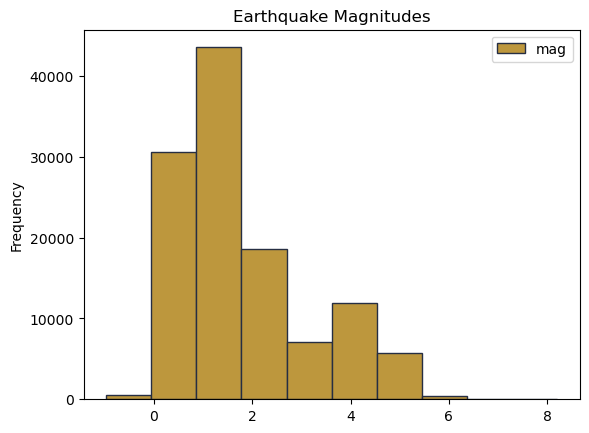

In [98]:
# Plotting frequency of earthquake manitudes as a histogram, setting the title and fill/edge color of bars
eqk.plot(kind = 'hist', y = 'mag', title = 'Earthquake Magnitudes', color = '#BD973D', edgecolor = '#262E43')

<!-- END QUESTION -->

# 7

a. Create a new variable `top20` with the 20 earthquakes with largest magnitude. HINT: check the method [`pandas.Series.nlargest`](https://pandas.pydata.org/docs/reference/api/pandas.Series.nlargest.html). Your answer should contain only the `id` and `mag` columns. 

In [86]:
# Selecting earthquake ids and magnitudes of the quakes with the 20 largest magnitudes
top20 = eqk.nlargest(n = 20,  keep = 'first', columns = 'mag')[['id', 'mag']]

In [87]:
# View the dataframe 
top20

,id,mag
36796,37371,8.2
49803,50562,7.9
36346,36918,7.7
33297,33808,7.6
31023,31496,7.5
33027,33537,7.4
94472,95913,7.3
31371,31850,7.2
33799,34318,7.1
104729,106285,7.1


In [88]:
grader.check("q7_a")

q7_a results:
    q7_a - 1 result:
        ❌ Test case failed
        Trying:
            assert pd.read_csv('data/t3_q7a_df.csv', index_col=0).equals(pd.DataFrame(top20))
        Expecting nothing
        **********************************************************************
        Line 1, in q7_a 0
        Failed example:
            assert pd.read_csv('data/t3_q7a_df.csv', index_col=0).equals(pd.DataFrame(top20))
        Exception raised:
            Traceback (most recent call last):
              File "/opt/miniforge3/envs/eds220/lib/python3.11/doctest.py", line 1351, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q7_a 0[0]>", line 1, in <module>
                assert pd.read_csv('data/t3_q7a_df.csv', index_col=0).equals(pd.DataFrame(top20))
            AssertionError

<!-- BEGIN QUESTION -->

b. Create a bar plot showing the magnitude of the top 20 earthquakes. Update the title, x-axis label, y-axis label, and color of the bars. 

<Axes: title={'center': 'Top 20 Earthquake Magnitudes'}, xlabel='Earthquake ID', ylabel='Earthquake Magnitude'>

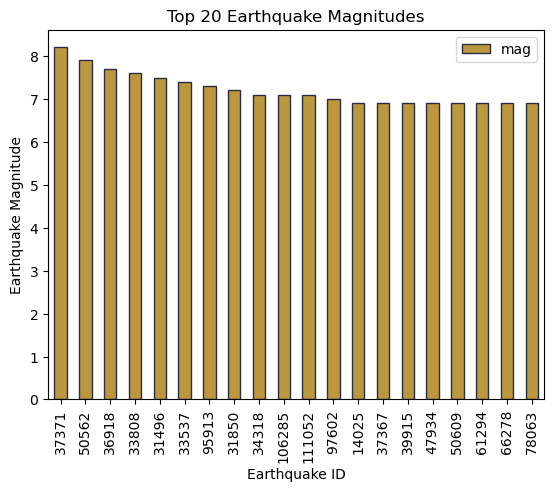

In [99]:
top20.plot(kind = 'bar', x = 'id', y = 'mag', title = 'Top 20 Earthquake Magnitudes', color = '#BD973D', edgecolor = '#262E43', xlabel = 'Earthquake ID', ylabel = 'Earthquake Magnitude')

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

c. What is the role of the `top20` index in the graph? What would have happened if we had not updated the index?

ANSWER THIS QUESTION

<!-- END QUESTION -->

# 8 
We are interested in the place, magnitude, and depth of the top 20 earthquakes with largest magnitude. Select this data from the `eqk` data frame. Store your answer in the `top20_filtered` variable. 

HINT: This is a "select rows and columns simultaneously" from `eqk` exercise. To select the rows you could use the index of `top20`. Make sure your columns are in the following order to pass the test: `place`, `mag`, `depth`. 

In [102]:
top20_filtered = eqk.loc[[top20['id']], ['id', 'place', 'mag', 'depth']]

KeyError: "None of [Index([(37371, 50562, 36918, 33808, 31496, 33537, 95913, 31850, 34318, 106285, 111052, 97602, 14025, 37367, 39915, 47934, 50609, 61294, 66278, 78063)], dtype='object')] are in the [index]"

In [91]:
# View the dataframe
top20_filtered

Ellipsis

In [92]:
grader.check("q8")

q8 results:
    q8 - 1 result:
        ❌ Test case failed
        Trying:
            assert pd.read_csv('data/t3_q8_df.csv', index_col=0).equals(top20_filtered)
        Expecting nothing
        **********************************************************************
        Line 1, in q8 0
        Failed example:
            assert pd.read_csv('data/t3_q8_df.csv', index_col=0).equals(top20_filtered)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/miniforge3/envs/eds220/lib/python3.11/doctest.py", line 1351, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q8 0[0]>", line 1, in <module>
                assert pd.read_csv('data/t3_q8_df.csv', index_col=0).equals(top20_filtered)
            AssertionError

<!-- BEGIN QUESTION -->

# 9 

Without creating any new variables, visualize the locations of eartquakes with magnitude greter than 5 by creating a scatter plot of their latitude and longitude. Make the following adjustments to the basic plot:
- update the title
- color the points by magnitude (HINT: [check the `c` parameter here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.scatter.html))
- adjust the `alpha` (transparency) argument
- adjust the `colormap` argument to maket it look prettier. [Click for ideas of sequential colormaps.](https://matplotlib.org/stable/users/explain/colors/colormaps.html)


---

To double-check your work, the cell below will rerun all of the autograder tests.

In [93]:
grader.check_all()

q1_c results: All test cases passed!

q2_a results: All test cases passed!

q2_b results: All test cases passed!

q2_c results: All test cases passed!

q3 results:
    q3 - 1 result:
        ❌ Test case failed
        Trying:
            unique_events.tolist() == list(raw_eqk.type.unique())
        Expecting:
            True
        **********************************************************************
        Line 1, in q3 0
        Failed example:
            unique_events.tolist() == list(raw_eqk.type.unique())
        Exception raised:
            Traceback (most recent call last):
              File "/opt/miniforge3/envs/eds220/lib/python3.11/doctest.py", line 1351, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q3 0[0]>", line 1, in <module>
                unique_events.tolist() == list(raw_eqk.type.unique())
                ^^^^^^^^^^^^^^^^^^^^
            AttributeError: 'int' object has no attribute 'tolist'

q4_a resul

<!-- END QUESTION -->

